In [1]:
from IPython.display import HTML
HTML('''
    <style> body {font-family: "Roboto Condensed Light", "Roboto Condensed";} h2 {padding: 10px 12px; background-color: #E64626; position: static; color: #ffffff; font-size: 40px;} .text_cell_render p { font-size: 15px; } .text_cell_render h1 { font-size: 30px; } h1 {padding: 10px 12px; background-color: #E64626; color: #ffffff; font-size: 40px;} .text_cell_render h3 { padding: 10px 12px; background-color: #0148A4; position: static; color: #ffffff; font-size: 20px;} h4:before{ 
    content: "@"; font-family:"Wingdings"; font-style:regular; margin-right: 4px;} .text_cell_render h4 {padding: 8px; font-family: "Roboto Condensed Light"; position: static; font-style: italic; background-color: #FFB800; color: #ffffff; font-size: 18px; text-align: center; border-radius: 5px;}input[type=submit] {background-color: #E64626; border: solid; border-color: #734036; color: white; padding: 8px 16px; text-decoration: none; margin: 4px 2px; cursor: pointer; border-radius: 20px;}</style>
''')

# Machine Learning

Utilising a Supervised Linear Regression, we will attempt to use some aspects of the data in earlier tables to estimate the school statistics missing from much of our dataset. In doing this we can potentially fill the gaps present, for a more involved, deep exploration into how bustling each SA2 region is.

First need to import that relevant libraries for our Linear Regression.

In [1]:
import pandas as pd
import matplotlib.pyplot  as plt
import seaborn as sns
from sklearn import linear_model
from sklearn import tree
from sklearn import metrics
from sklearn.model_selection import KFold, cross_val_score
from sklearn.model_selection import train_test_split

Next we need to load our data into a Dataframe to prepare it. This includes separating our variables.

In [28]:
data = pd.read_csv("Task 3 Combined Data.csv")
input_columns = ['num_0_19_people','young_perc','num_stops','num_schools','median_income','total_turnover']
data.columns

Index(['Unnamed: 0', 'SA2_CODE21', 'SA2_NAME21', 'SA3_NAME21', 'SA4_NAME21',
       'STE_NAME21', 'GCC_NAME21', 'geom', 'area_size', 'num_polls',
       'num_schools', 'num_stops', 'num_earners', 'median_age',
       'median_income', 'mean_income', 'total_businesses', 'total_turnover',
       'num_0_19_people', 'young_perc', 'total_people', 'poi_weights',
       'green_weights', 'exams_sat', 'hsc_student', 'school_achievement'],
      dtype='object')

We plan on using a Linear regression, which demands all null values are dealt with. First we count the number of values present in each column we will be using. Since we intend to use this model to predict for null values, for the best result, we will drop all null values.

Unfortunately this leaves us with only 117 data points remaining, which may result in a poor model.

In [29]:
data_clean = data[['num_0_19_people','young_perc','num_stops','num_schools','median_income','total_turnover','exams_sat']].copy()
data_clean.dropna(inplace=True)
len(data_clean)


117

Finally we can create our Model, separating the target variable from the rest, and splitting the data into Training and Testing.

In [45]:
X = data_clean[input_columns]
Y = data_clean['exams_sat']
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.1, random_state = 45)
regression_model = linear_model.LinearRegression().fit(X_train, Y_train)

From here we can then determine how effective our model is at determining the TARGET VARIABLE. 
- Root Mean Squared Error as it provides a good glimpse at the accuracy of our model. 
- R-Squared is used to see if the variables we've chosen are indeed correlated to what we estimate. 
- Max Error to gauge the worst of our model.

The first problem to note is the substantial value of the RMSE, which details that there are fundametal issues currently present in our model, and that we either need to reconsider how we create our model, or reject the idea entirely.

Even more problematic is the minimal correlation between our estimates, and true values. While it certainly could be worse, a value of 0.30 shows little to no actual correlation.

Finally, we can see the largest error our model has resulted in is approximately 882, which when dealing with numbers between 0-1600 once more represents that our model is unfit for its purpose.

In [31]:
Y_predictions = regression_model.predict(X_test)
mse_metric = metrics.root_mean_squared_error(Y_test, Y_predictions)
r2_metric = metrics.r2_score(Y_test,Y_predictions)
max_error = metrics.max_error(Y_test,Y_predictions)
mse_metric, r2_metric, max_error

(516.4603929895875, 0.30108408685953203, 882.1226255479037)

Plotting the true values against the estimated values gives us a strong intuition on how accurate our model is. 

Ideally we should get a 1-to-1 correlation, but as we can see (both from our plot and the 0.120 we got from the metrics).

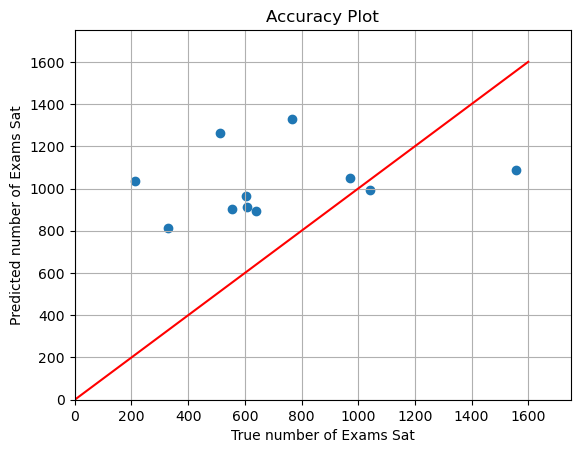

In [32]:
plt.scatter(Y_test,Y_predictions)
plt.title('Accuracy Plot')
plt.xlabel('True number of Exams Sat')
plt.ylabel('Predicted number of Exams Sat')
plt.xlim(0,1750)
plt.ylim(0,1750)
plt.grid()
plt.plot([0,1600],[0,1600],color='red')


Additionally, by plotting the sorted distances between the real values and predictions, we can see how often we over-estimate compared to under-estimate; but more importantly, how often we accurately guess close to the real value. 

Looking at the results we can see our Model is far more prone to overestimating the number of exams sat, rather than underestimating.

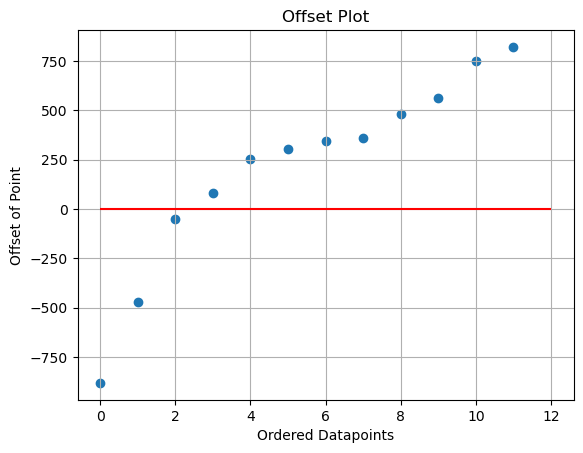

In [34]:
offsets =list(Y_predictions - Y_test)
offsets.sort()
plt.scatter(range(len(offsets)),offsets)
plt.title('Offset Plot')
plt.xlabel('Ordered Datapoints')
plt.ylabel('Offset of Point')
plt.grid()
plt.hlines(0,xmin=0,xmax=12,color='red')

One possible issue is in our original assumption of correlation between 'exams sat' and the other variables we have access to. Plotting a Correlation matrix we can see that this is indeed correct, and the actual level of correlation is insubstantial.

<Axes: >

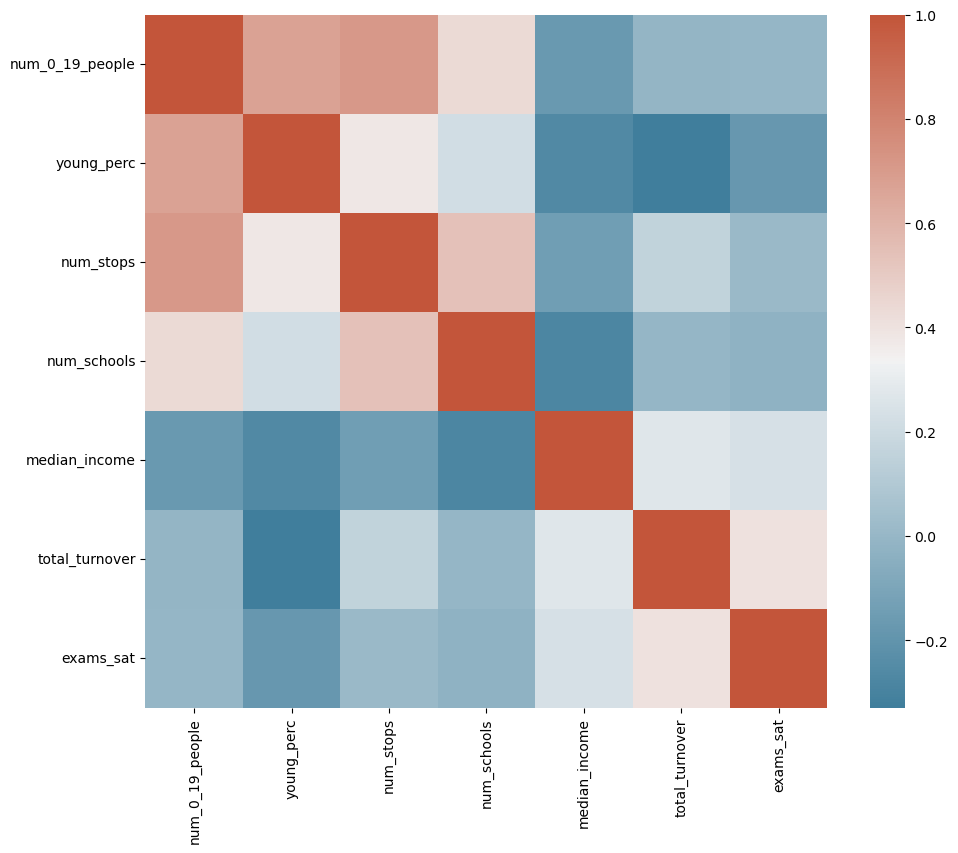

In [35]:
numeric_columns = list(data.columns)[9:]
corr = data_clean.corr()
f, ax = plt.subplots(figsize=(11, 9))
cmap = sns.diverging_palette(230, 20, sep=1, center='light', as_cmap=True)
sns.heatmap(corr,cmap=cmap)

In conclusion, with the current areas of data we have access to, we cannot create a reliable model to estimate the number of exams sat in the related SA2 areas.